# 🪸 CoralMorph Search — Project Demo

**CoralMorph Search** is a semantic search engine for marine researchers and reef enthusiasts. Instead of matching exact keywords, it lets you type a natural-language description — e.g. *"spiky green branches in shallow water"* — and returns the coral species whose descriptions are most *semantically* similar, using sentence embeddings and vector similarity search.

## Architecture: ingest → vectorize → store → search

```
Coral_reef_data.csv
        │
        ▼
  data_preparation.py   ── cleans text, engineers a "search_text" field,
        │                  writes cleaned_coral_data.parquet
        ▼
  vectorize_and_store.py ── embeds search_text with Sentence-Transformers
        │                  (all-MiniLM-L6-v2, 384-dim) and upserts the
        │                  vectors + metadata into a Qdrant collection
        ▼
     Qdrant (vector DB, docker-compose service)
        │
        ▼
      main.py  ── FastAPI backend. Loads the same embedding model once,
        │         embeds the incoming query, asks Qdrant for nearest
        │         neighbours, and returns them as JSON.
        ▼
   frontend/ (React + Tailwind SPA) ── search bar + results grid that
                                        calls GET /api/search/?q=...
```

### A note on the codebase
Reading through the repo, there are actually **two parallel implementations** of the storage layer that are worth calling out for this demo:

- **The "live" path** — `data_preparation.py` → `vectorize_and_store.py` → `main.py` — uses **Qdrant** as the vector database. This matches `docker-compose.yml` (which spins up a `qdrant` service) and is what the FastAPI backend in `main.py` actually queries.
- **An older / alternate path** — `ingest_data.py`, `test_search.py`, `validate_embeddings.py`, `e2e_test.py` — uses **DuckDB** with `list_cosine_similarity(...)` SQL and a local `coral_morph.db` file. This matches the PRD's original design and the README's mention of DuckDB, but isn't what `main.py` is wired up to today.

Both approaches share the same core idea (embed a structured `search_text` string per species with `all-MiniLM-L6-v2`, then rank by cosine similarity), so this notebook demonstrates that shared concept once, and then shows both the Qdrant-based API surface (`main.py`) and the DuckDB-based query pattern (`test_search.py` / `validate_embeddings.py`) as code walkthroughs.

### Why this notebook doesn't run the real pipeline
`vectorize_and_store.py` / `ingest_data.py` need a downloaded Sentence-Transformers model plus a running Qdrant (or DuckDB file), and `main.py` needs that Qdrant instance live at query time. None of that is available in this sandboxed environment, so instead this notebook:
1. Loads and explores the **real** `Coral_reef_data.csv`.
2. Walks through the real pipeline code with explanations.
3. **Simulates** the embed → store → search flow locally with a lightweight TF‑IDF vectorizer + cosine similarity (a stand-in for the real sentence-transformer embeddings) so you can see the search behavior end-to-end without any external services.

## 1. Load and preview the raw dataset

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

# The CSV has non-UTF-8 characters (curly quotes etc.), same encoding
# data_preparation.py uses to load it robustly.
raw_df = pd.read_csv('Coral_reef_data.csv', encoding='ISO-8859-1')

print('Shape:', raw_df.shape)
print('Columns:', list(raw_df.columns))
raw_df.head(3)

Shape: (831, 10)
Columns: ['Species Name ', 'Authority / Year', 'Characters:', 'Description', 'Colour:', 'Color', 'Habitat:', 'Habitat', 'Abundance:', 'Abundance']


,Species Name,Authority / Year,Characters:,Description,Colour:,Color,Habitat:,Habitat,Abundance:,Abundance
0,Acanthastrea bowerbanki,"Haime and Milne Edwards, 1857",Characters:,"Colonies are encrusting and usually small. Corallites are cerioid, with irregular angular shapes. A central corallit...",Colour:,"Usually pale grey, brown or rust coloured, often mottled.",Habitat:,Lower reef slopes protected from wave action.,Abundance:,Rare except in subtropical localities of eastern Australia.
1,Acanthastrea brevis,"Milne Edwards and Haime, 1849",Characters:,Colonies are mostly submassive. Corallites are cerioid to subplocoid with moderately thin walls. Septa are thin and ...,Colour:,"Uniform or mottled brown, yellow or green.",Habitat:,Shallow reef environments.,Abundance:,Uncommon.
2,Acanthastrea echinata,"(Dana, 1846)",Characters:,"Colonies are encrusting to massive and are rarely over one metre across. Corallites are cerioid or subplocoid, circu...",Colour:,"Uniform or mottled dull brown, grey or green, but sometimes brightly coloured.",Habitat:,Most reef environments.,Abundance:,"Usually uncommon, but by far the most common on tropical reefs."


### The column layout is a bit unusual
The CSV alternates *label* columns (`Characters:`, `Colour:`, `Habitat:`, `Abundance:`) with the actual *value* columns (`Description`, `Color`, `Habitat`, `Abundance`). Both `data_preparation.py` and `ingest_data.py` handle this the same way — by selecting columns **positionally by index** rather than by name, then renaming them:

```python
column_mapping = {
    df.columns[0]: "species_name",
    df.columns[3]: "description",
    df.columns[5]: "color",
    df.columns[7]: "habitat",
    df.columns[9]: "abundance",
}
```

We reproduce that same mapping below.

In [2]:
column_mapping = {
    raw_df.columns[0]: "species_name",
    raw_df.columns[3]: "description",
    raw_df.columns[5]: "color",
    raw_df.columns[7]: "habitat",
    raw_df.columns[9]: "abundance",
}

df = raw_df.rename(columns=column_mapping)[["species_name", "description", "color", "habitat", "abundance"]].copy()

def clean_text(text):
    """Same cleaning logic as data_preparation.py: fill blanks, collapse whitespace."""
    if pd.isna(text) or text == "":
        return "Not specified"
    return re.sub(r'\s+', ' ', str(text)).strip()

for col in df.columns:
    df[col] = df[col].apply(clean_text)

print('Cleaned shape:', df.shape)
df.head(5)

Cleaned shape: (831, 5)


,species_name,description,color,habitat,abundance
0,Acanthastrea bowerbanki,"Colonies are encrusting and usually small. Corallites are cerioid, with irregular angular shapes. A central corallit...","Usually pale grey, brown or rust coloured, often mottled.",Lower reef slopes protected from wave action.,Rare except in subtropical localities of eastern Australia.
1,Acanthastrea brevis,Colonies are mostly submassive. Corallites are cerioid to subplocoid with moderately thin walls. Septa are thin and ...,"Uniform or mottled brown, yellow or green.",Shallow reef environments.,Uncommon.
2,Acanthastrea echinata,"Colonies are encrusting to massive and are rarely over one metre across. Corallites are cerioid or subplocoid, circu...","Uniform or mottled dull brown, grey or green, but sometimes brightly coloured.",Most reef environments.,"Usually uncommon, but by far the most common on tropical reefs."
3,Acanthastrea faviaformis,"Colonies are encrusting to massive, usually less than 0.2 metres across. Most consist of a small number of encrustin...",Mottled browns.,Shallow reef environments.,Uncommon.
4,Acanthastrea hemprichii,Colonies are encrusting to massive and frequently over one metre across. Corallites are cerioid. Septa have exsert t...,"Mottled browns and greens, commonly with brown walls and green oral discs.",Most reef environments.,Uncommon.


## 2. Quick exploratory data analysis

A few questions worth answering before we build a search index: how much text do we actually have per species, how many distinct habitats/colors show up, and how are species distributed across abundance categories?

In [3]:
df['description_length'] = df['description'].apply(len)

print('Species with usable descriptions:', (df['description'] != 'Not specified').sum(), '/', len(df))
print()
print(df['description_length'].describe())

Species with usable descriptions: 831 / 831

count    831.000000
mean     264.501805
std       92.893408
min       77.000000
25%      203.000000
50%      254.000000
75%      321.000000
max      983.000000
Name: description_length, dtype: float64


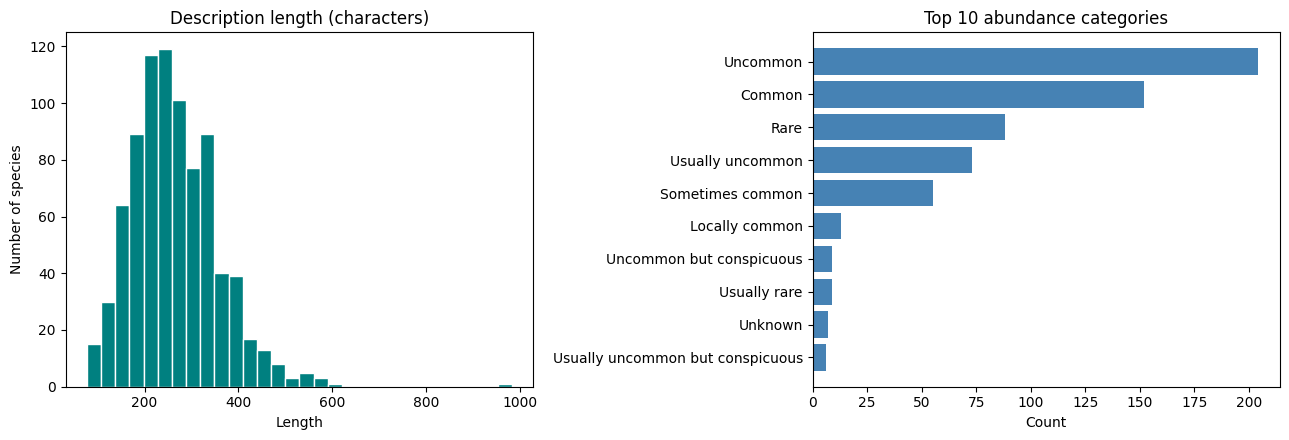

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['description_length'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Description length (characters)')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Number of species')

df['abundance_short'] = df['abundance'].str.split('.').str[0].str.strip()
top_abundance = df['abundance_short'].value_counts().head(10).sort_values()
axes[1].barh(top_abundance.index, top_abundance.values, color='steelblue')
axes[1].set_title('Top 10 abundance categories')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [5]:
# Primary habitat (first listed habitat), same feature engineering step as data_preparation.py
df['primary_habitat'] = df['habitat'].str.split(',').str[0].str.split(';').str[0].str.strip()

print('Distinct primary habitats:', df['primary_habitat'].nunique())
df['primary_habitat'].value_counts().head(10)

Distinct primary habitats: 375


primary_habitat
Shallow reef environments.              147
Most reef environments.                  44
Upper reef slopes.                       35
Reef slopes and lagoons.                 18
Shallow protected reef environments.     15
Reef slopes.                             13
Shallow reef environments                13
Reef habitats.                           13
Upper reef slopes and lagoons.           11
Most reef environments                   11
Name: count, dtype: int64

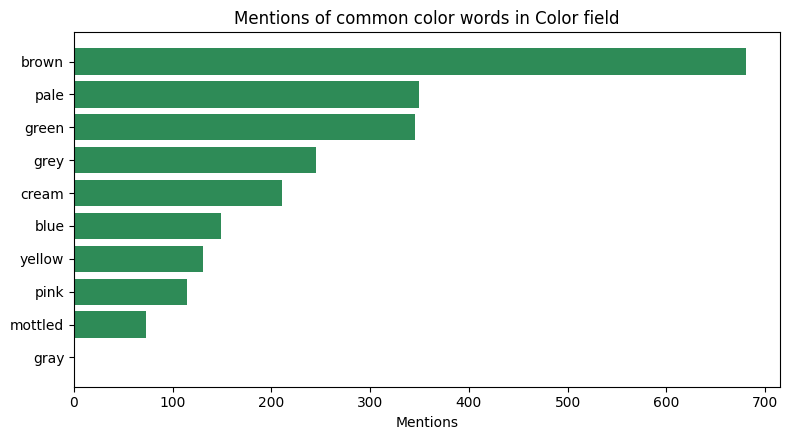

In [6]:
# Common color words mentioned across all species (borrowed idea from Coral_EDA.ipynb)
colors_text = ' '.join(df['color'].str.lower())
common_colors = ['brown', 'grey', 'gray', 'green', 'cream', 'blue', 'pink', 'yellow', 'mottled', 'pale']
color_counts = pd.Series({c: colors_text.count(c) for c in common_colors}).sort_values()

plt.figure(figsize=(8, 4.5))
plt.barh(color_counts.index, color_counts.values, color='seagreen')
plt.title('Mentions of common color words in Color field')
plt.xlabel('Mentions')
plt.tight_layout()
plt.show()

## 3. The real pipeline: feature engineering + embeddings

Both `data_preparation.py` and `ingest_data.py` build a single **`search_text`** string per species that concatenates all the descriptive fields into one prompt-like passage. This is the text that actually gets embedded — the idea being that a sentence-transformer can pick up semantic signal spread across species name, physical traits, color, habitat, and abundance all at once.

From `data_preparation.py`:
```python
df['search_text'] = (
    "Species: " + df["species_name"] + ". " +
    "Physical Traits: " + df["description"] + ". " +
    "Visual Appearance: " + df["color"] + ". " +
    "Natural Habitat: " + df["habitat"] + ". " +
    "Population Status: " + df["abundance"] + "."
)
```

From `vectorize_and_store.py`, that text is embedded with Sentence-Transformers and pushed into Qdrant:
```python
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['search_text'].tolist(), show_progress_bar=True)

client.recreate_collection(
    collection_name="corals",
    vectors_config=VectorParams(size=384, distance=Distance.COSINE),
)
points = [
    PointStruct(id=idx, vector=embeddings[idx].tolist(), payload=row.to_dict())
    for idx, row in df.iterrows()
]
client.upsert(collection_name="corals", wait=True, points=points)
```

The DuckDB variant (`ingest_data.py`) does the same embedding step but stores vectors in a local `FLOAT[]` column and later queries with `list_cosine_similarity(embedding, ?)` in SQL (see `test_search.py` / `validate_embeddings.py`).

Let's build that same `search_text` column here.

In [7]:
df['search_text'] = (
    "Species: " + df["species_name"] + ". " +
    "Physical Traits: " + df["description"] + ". " +
    "Visual Appearance: " + df["color"] + ". " +
    "Natural Habitat: " + df["habitat"] + ". " +
    "Population Status: " + df["abundance"] + "."
)

df[['species_name', 'search_text']].head(2)

,species_name,search_text
0,Acanthastrea bowerbanki,Species: Acanthastrea bowerbanki. Physical Traits: Colonies are encrusting and usually small. Corallites are cerioid...
1,Acanthastrea brevis,Species: Acanthastrea brevis. Physical Traits: Colonies are mostly submassive. Corallites are cerioid to subplocoid ...


## 4. Simulating the search: local toy embeddings

We can't download `all-MiniLM-L6-v2` or talk to a Qdrant/DuckDB instance in this sandbox, so instead we build a **lightweight local stand-in** using scikit-learn's TF‑IDF vectorizer over the same `search_text` field, then rank species by **cosine similarity** to a query — exactly the same *shape* of computation the real pipeline performs (`list_cosine_similarity` in DuckDB, or Qdrant's COSINE distance), just with a much simpler/cheaper embedding.

This is purely illustrative: TF-IDF captures lexical overlap, not the deeper semantic similarity a sentence-transformer would, but it's enough to demonstrate the retrieval mechanics end-to-end without any network access or external services.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
doc_matrix = vectorizer.fit_transform(df['search_text'])

print('Toy "embedding" matrix shape:', doc_matrix.shape, '(rows = species, columns = TF-IDF vocab terms)')

def toy_search(query, top_k=5):
    """Local stand-in for main.py's /api/search/ endpoint:
    embed the query, rank corpus by cosine similarity, return top_k.
    """
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, doc_matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_idx][['species_name', 'color', 'habitat', 'abundance', 'description']].copy()
    results.insert(1, 'score', scores[top_idx].round(4))
    return results.reset_index(drop=True)

toy_search('spiky green branches in shallow water')

Toy "embedding" matrix shape: (831, 2255) (rows = species, columns = TF-IDF vocab terms)


,species_name,score,color,habitat,abundance,description
0,Acropora sekiseiensis,0.2932,Brown.,Shallow lagoons and reefs.,Sometimes common.,Colonies have irregularly prostrate branches with short sub-branches and may form extensive thickets. Axial corallit...
1,Acropora pharaonis,0.2639,"Grey-brown, usually with pale branch tips.",Sheltered reef slopes.,May be locally common.,Colonies are large horizontal tables or irregular clusters of horizontal or upright interlinked contorted branches. ...
2,Acropora cerealis,0.2581,"Mostly pale brown, cream or white, with purple, pink, blue or cream branch tips.",Upper reef slopes.,Common.,"Colonies are caespitose or corymbose, composed of branches which interlock in three dimensions. Branches are thin, w..."
3,Acropora akajimensis,0.2486,"Brown, blue and yellow.",Shallow reef slopes and flats.,"Occasionally locally common, usually rare.","Colonies consist of dense thickets of prostrate tapered, curving branches which occasionally fuse. Sub-branches are ..."
4,Acropora massawensis,0.2005,White to pale brown.,Upper reef slopes.,Uncommon.,Colonies form extensive flat digitate clumps or thickets composed of branchlets of similar length and shape. Axial c...


In [9]:
# A couple more example queries, in the same spirit as the PRD's user stories
for q in [
    'bright blue small polyps',
    'branching structures with high calcification in deep lagoons',
    'encrusting colonies on lower reef slopes',
]:
    print(f'Query: "{q}"')
    display(toy_search(q, top_k=3)[['species_name', 'score', 'habitat']])
    print()

Query: "bright blue small polyps"


,species_name,score,habitat
0,Montipora verrucosa,0.2553,Upper reef slopes and lagoons.
1,Fungia scutaria,0.2511,Found with other species and also on upper reef slopes exposed to strong wave action.
2,Acropora aspera,0.2472,"Reef flats and shallow lagoons, also exposed upper reef slopes and occasionally deep water."



Query: "branching structures with high calcification in deep lagoons"


,species_name,score,habitat
0,Schizoculina fissipara,0.2205,Rocky foreshores up to 35 metres deep.
1,Porites cylindrica,0.2032,May be a dominant species in lagoons or on back reef margins.
2,Australogyra zelli,0.2024,Usually in turbid waters around high islands or in reef lagoons.



Query: "encrusting colonies on lower reef slopes"


,species_name,score,habitat
0,Galaxea paucisepta,0.2816,Lower reef slopes protected from wave action.
1,Porites nigrescens,0.2478,Common on lower reef slopes and lagoons protected from wave action.
2,Alveopora ocellata,0.2372,Lower reef slopes protected from wave action.


## 5. The API layer: `main.py`

`main.py` is a small FastAPI app with two endpoints:

| Endpoint | Method | Purpose |
|---|---|---|
| `/api/search/` | GET | Semantic search. Params: `q` (required query string), `limit` (optional, default 10, 1-100). Embeds `q` with the same `all-MiniLM-L6-v2` model (loaded once via a lazy singleton `ModelLoader`), queries Qdrant's `corals` collection for nearest neighbours, and returns them. |
| `/health` | GET | Liveness check — returns model name and backing store. |

Core search logic from `main.py`:
```python
@app.get("/api/search/", response_model=SearchResponse)
async def search(q: str = Query(...), limit: int = Query(10, ge=1, le=100)):
    model = ModelLoader.get_model()
    query_vector = model.encode([q])[0].tolist()
    search_results = qdrant_client.search(
        collection_name="corals", query_vector=query_vector,
        limit=limit, with_payload=True,
    )
    ...
    return SearchResponse(query=q, results=formatted_results)
```

The DuckDB-based scripts (`test_search.py`, `validate_embeddings.py`) do the equivalent lookup as raw SQL:
```sql
SELECT species_name, color, habitat, description,
       list_cosine_similarity(embedding, ?) AS similarity_score
FROM corals
ORDER BY similarity_score DESC
LIMIT ?
```

### Example request / response
```
GET http://localhost:8000/api/search/?q=shallow%20green%20coral&limit=1
```
```json
{
  "query": "shallow green coral",
  "results": [
    {
      "species_name": "Acropora pruinosa",
      "score": 0.468,
      "color": "Greenish and brown",
      "habitat": "Shallow turbid water",
      "description": "..."
    }
  ]
}
```

An empty `q` returns HTTP 400 with a consistent error envelope (per the README):
```json
{
  "error": {
    "code": "MISSING_QUERY",
    "message": "Query parameter 'q' is required.",
    "details": { "parameter": "q" }
  }
}
```
The README also documents rate limiting (60 req/min anonymous, 120/min authenticated) and response caching (keyed by `(query, limit)`, 300s TTL) — both configurable via environment variables.

Below we reproduce the **shape** of a `/api/search/` response using our local TF‑IDF `toy_search` in place of the real model + Qdrant call.

In [10]:
import json

def simulate_api_response(q, limit=5):
    """Mimics main.py's SearchResponse shape, using toy_search instead of
    SentenceTransformer + Qdrant.
    """
    if not q.strip():
        return {
            "error": {
                "code": "MISSING_QUERY",
                "message": "Query parameter 'q' is required.",
                "details": {"parameter": "q"},
            }
        }
    hits = toy_search(q, top_k=limit)
    return {
        "query": q,
        "results": [
            {
                "species_name": row.species_name,
                "color": row.color,
                "habitat": row.habitat,
                "abundance": row.abundance,
                "score": row.score,
                "description": row.description[:120] + "...",
            }
            for row in hits.itertuples()
        ],
    }

print(json.dumps(simulate_api_response('shallow green coral', limit=2), indent=2))

{
  "query": "shallow green coral",
  "results": [
    {
      "species_name": "Porites columnaris",
      "color": "Pale brown.",
      "habitat": "Shallow reef environments.",
      "abundance": "The dominant coral in Kaneohe Bay, Hawaii.",
      "score": 0.306,
      "description": "Colonies are submassive or form short columns which may branch. These have a smooth surface...."
    },
    {
      "species_name": "Echinophyllia tarae",
      "color": "Green, brown or mottled usually with distinctively coloured corallites.",
      "habitat": "Sheltered reef environments.",
      "abundance": "Rare.",
      "score": 0.252,
      "description": "The coral is flat, encrusting. It usually consists of a single large corallite but may also have smaller peripheral cora..."
    }
  ]
}


## Summary

This notebook walked through **CoralMorph Search** end-to-end without needing any external services:

- Loaded and cleaned the real `Coral_reef_data.csv` (831 species, awkward alternating-column layout) the same way `data_preparation.py` / `ingest_data.py` do.
- Explored description lengths, abundance categories, primary habitats, and common color terms.
- Rebuilt the `search_text` feature that the real pipeline embeds with `all-MiniLM-L6-v2`.
- Walked through the actual embedding + storage code in `vectorize_and_store.py` (Qdrant) and the alternate DuckDB path (`ingest_data.py`, `test_search.py`), noting that `main.py` is currently wired to the **Qdrant** path.
- Simulated the semantic search behavior locally with TF‑IDF + cosine similarity as a stand-in for the real embedding model, and confirmed the retrieval mechanics work as expected on sample queries.
- Reproduced the `/api/search/` request/response shape (and its error envelope) that the FastAPI backend and React frontend rely on.

To run the real thing: `docker-compose up` (starts Qdrant + the FastAPI backend + frontend), after running `data_preparation.py` and `vectorize_and_store.py` once to populate the vector store.